**Why this notebook auto-reloads code**

The next cell enables IPython's `autoreload` so changes you make in the `netsci` module are picked up automatically before each cell runs, without restarting the kernel.

Reference: https://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython


In [1]:
# Auto-reload netsci modules if code changes
%load_ext autoreload
%autoreload 2


# Week 3: Random Networks & Small Worlds

**Learning objectives** — After this lab you should be able to:

- Explain the Erdos-Renyi model and its Poisson degree distribution
- Describe the largest component phase transition at avg degree ⟨k⟩ = 1
- Explain the "six degrees of separation" phenomenon
- Define the small-world property (high clustering + short paths)
- Build and explore Watts-Strogatz graphs at varying rewiring probabilities
- Reproduce the classic C(p)/L(p) vs p plot
- Explain Kleinberg's navigable small-world model and greedy routing
- Test whether real networks exhibit the small-world property

In the 1960s, psychologist Stanley Milgram ran a famous experiment: he asked random people
in Nebraska to forward a letter to a target person in Boston by passing it through personal
acquaintances. The letters that arrived took, on average, only about **six steps**.

This "six degrees of separation" idea suggests that even very large networks can have
surprisingly **short paths**. But how is this compatible with the tight friend-groups
(high clustering) we see in real social networks? This week we build up from the simplest
random graph model to increasingly realistic small-world models.

In [2]:
import networkx as nx
import numpy as np
from netsci.loaders import load_graph
from netsci.utils import SEED, graph_summary, small_world_table
from netsci.models import greedy_route
from netsci import viz, models

---
## 1. Datasets

We use two real-world networks this week:

- **US Airports** (500 nodes, ~2,980 edges) -- flight routes between airports. An obvious small-world candidate: you can fly between almost any two cities with just 1-2 layovers, yet airports tend to cluster regionally.
- **EU Email** (1,005 nodes, ~25,571 edges) -- email exchange between members of a European research institution. Email acts as an information-flow proxy: departments form tight clusters, but interdepartmental messages create shortcuts.

In [3]:
G_air = load_graph("airports")
graph_summary(G_air)
print()
G_email = load_graph("email")
graph_summary(G_email)

airports: 500 nodes, 2980 edges (undirected)
Graph Summary: Graph
  Type:        undirected
  Nodes:       500
  Edges:       2980
  Density:     0.0239
  Avg degree:  11.92
  Components:  1
  Avg clustering: 0.6175



email: 1005 nodes, 25571 edges (directed)
Graph Summary: Graph
  Type:        directed
  Nodes:       1005
  Edges:       25571
  Density:     0.0253
  Avg degree:  50.89
  Components:  20


---
## 2. Six Degrees of Separation

Let's check: how many hops does it actually take to get between two random airports?

In [4]:
apl_air = nx.average_shortest_path_length(G_air)
diam_air = nx.diameter(G_air)
print(f"Airports: {G_air.number_of_nodes()} nodes")
print(f"  Average shortest path length: {apl_air:.2f}")
print(f"  Diameter: {diam_air}")
print(f"\nEven among 500 airports, the average separation is only ~{apl_air:.1f} hops!")

Airports: 500 nodes
  Average shortest path length: 2.99
  Diameter: 7

Even among 500 airports, the average separation is only ~3.0 hops!


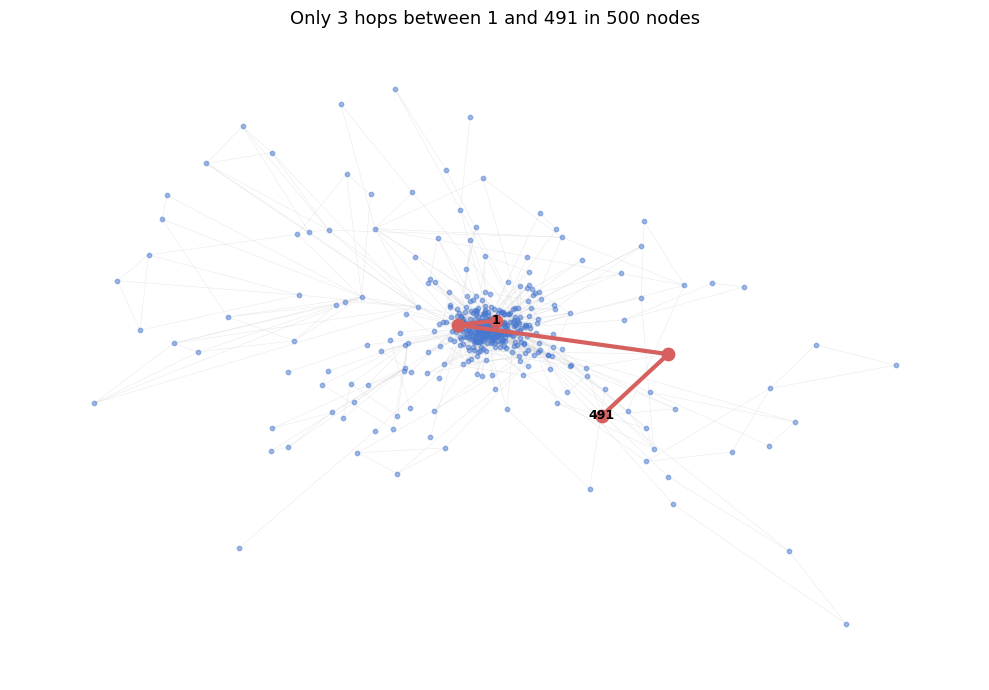

In [5]:
# Shortest path highlighted on the airport network
nodes_air = list(G_air.nodes())
src, tgt = nodes_air[0], nodes_air[-1]
pos = nx.spring_layout(G_air, seed=SEED)
viz.plot_shortest_path(G_air, src, tgt, pos=pos)

**Visualizing "six degrees"**: The red path above shows the shortest route between two airports. Despite the network having 500 nodes, most pairs are only 2-3 hops apart. The gray tangle of edges is what makes this possible — there are many alternative routes, and hub airports act as express connectors.

---
## 3. The Erdos-Renyi Random Model

Before we can define what makes a network "small-world," we need a **random baseline** to compare against. The Erdos-Renyi (ER) model is the simplest possible random graph: flip a biased coin for every pair of nodes — heads means they get an edge, tails means they don't.

The edge probability p is set via a chosen average degree. Because each edge is independent, the resulting degree distribution is **Poisson** (bell-shaped), which means all nodes have roughly similar degree — no hubs.

In [6]:
G_er = models.erdos_renyi(n=500, avg_degree=6)
graph_summary(G_er)
print(f"Max degree: {max(d for _, d in G_er.degree())}")

Graph Summary: Graph
  Type:        undirected
  Nodes:       500
  Edges:       1489
  Density:     0.0119
  Avg degree:  5.96
  Components:  1
  Avg clustering: 0.0111
Max degree: 16


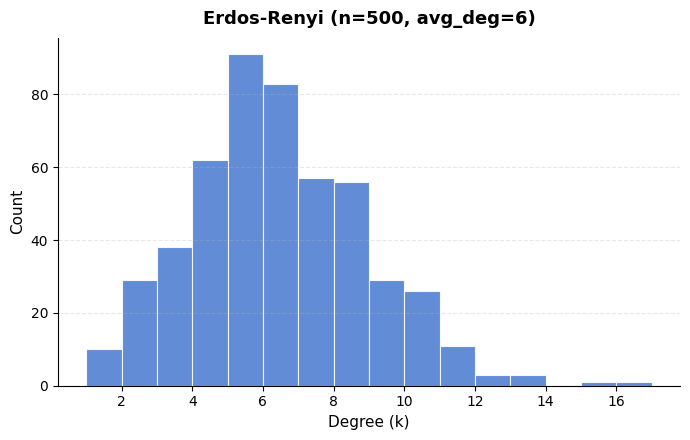

In [7]:
viz.plot_degree_dist(G_er, title="Erdos-Renyi (n=500, avg_deg=6)")

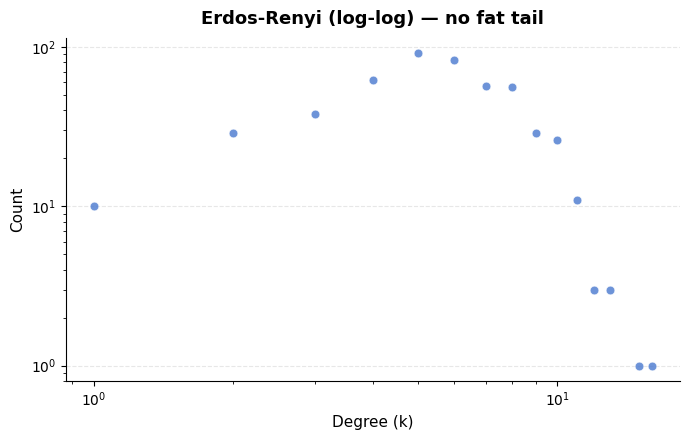

In [8]:
viz.plot_degree_dist(G_er, log=True, title="Erdos-Renyi (log-log) — no fat tail")

**Reading the log-log plot**: The ER degree distribution curves *downward* on a log-log scale — this is the signature of an exponential (Poisson) tail. Real networks like airports follow a roughly straight line (power law). We'll explore this gap in Week 4.

### Phase Transition in ER Graphs

Something interesting happens as we increase the average degree ⟨k⟩: a single connected component suddenly absorbs most of the network.

**Why is ⟨k⟩ = 1 the theoretical threshold?** Think of exploring the network from a random node. Each neighbor you visit leads to ⟨k⟩ - 1 *new* neighbors on average (excluding the one you came from). When ⟨k⟩ < 1 this branching process dies out quickly — components stay tiny. When ⟨k⟩ > 1 each step *multiplies* the frontier, triggering explosive growth that sweeps up most of the network. The critical point ⟨k⟩ = 1 is where this switch flips — one of the sharpest phase transitions in random graph theory.

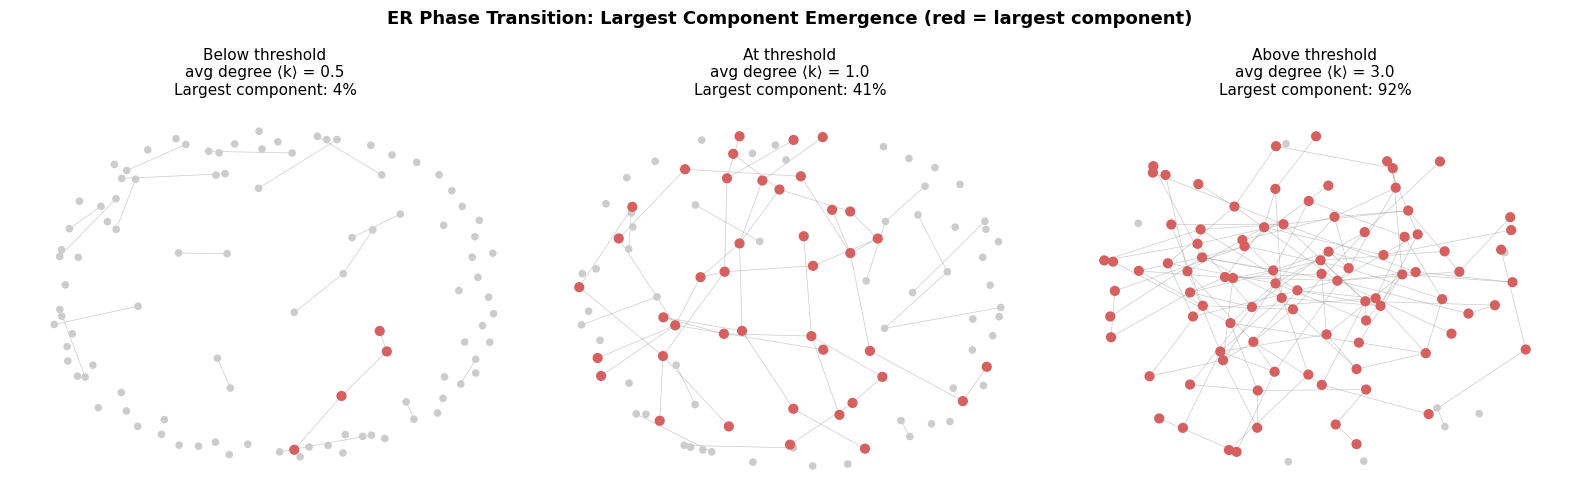

In [9]:
viz.plot_er_phase_panels(n=100)

**Reading the panels**: At ⟨k⟩ = 0.5 (left) you see many tiny, disconnected fragments — the largest component is just a handful of nodes. At ⟨k⟩ = 1.0 (center) a single component has already captured a large share. By ⟨k⟩ = 3.0 (right) nearly every node belongs to it.

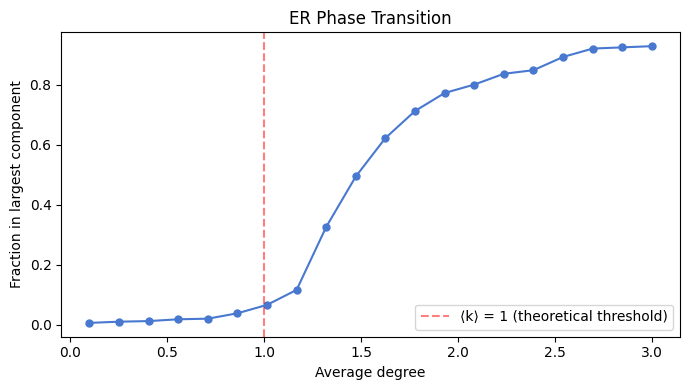

In [10]:
# Phase transition: vary average degree, track largest component size
n_phase = 500
avg_degrees = np.linspace(0.1, 3.0, 20)
gcc_sizes = []

for avg_d in avg_degrees:
    G_tmp = models.erdos_renyi(n_phase, avg_d)
    gcc = max(nx.connected_components(G_tmp), key=len)
    gcc_sizes.append(len(gcc) / n_phase)

viz.plot_er_phase_sweep(avg_degrees, gcc_sizes)

**Reading the sweep**: The red dashed line marks the theoretical ⟨k⟩ = 1 threshold. Notice the curve rises steeply right around that point — this is the phase transition in action. For finite graphs like ours (n = 500), the empirical inflection may appear slightly above 1 due to finite-size effects; in the limit n → ∞ it converges exactly to ⟨k⟩ = 1.

---
## 4. The Small-World Property

A network has the **small-world property** if it has:
1. **High clustering** (much higher than a random graph of the same size)
2. **Short average path length** (comparable to a random graph of the same size)

**Why are these two properties surprising together?** In most simple models they trade off against each other. A regular lattice (think of a grid or ring where you only know your immediate neighbors) has very high clustering — your friends are also friends with each other — but path lengths are long because information must hop through many local steps to cross the network. A purely random graph (like Erdős–Rényi) has short paths thanks to random long-range connections, but clustering is negligible because there is no reason for your neighbors to know each other.

Real social networks somehow achieve *both*: your friend group is tightly knit (high C), yet you are only a few handshakes away from anyone on the planet (low L). This is the "small-world" puzzle — and it is exactly what Milgram's six-degrees experiment revealed. The combination works because a small number of long-range shortcuts (friends in other cities, weak ties across departments) drastically cut path lengths while barely disturbing the local clustering among close contacts.

We quantify this with the **small-world coefficient**:

$$\sigma = \frac{C_{\text{real}} \;/\; C_{\text{random}}}{L_{\text{real}} \;/\; L_{\text{random}}}$$

The numerator captures how much *more* clustered the real network is compared to a random graph with the same size and density. The denominator captures how much *longer* its paths are. A true small world has a large numerator (clustering far exceeds random) and a denominator near 1 (paths are comparable), so σ >> 1.

Let's test this for both the airports and email networks by comparing them to Erdős–Rényi baselines.

In [11]:
# Email network is directed — convert to undirected for APL
G_email_u = G_email.to_undirected()

# Use largest connected component for both
G_air_cc = G_air.subgraph(max(nx.connected_components(G_air), key=len)).copy()
G_email_cc = G_email_u.subgraph(max(nx.connected_components(G_email_u), key=len)).copy()

small_world_table(G_air_cc, "US Airports")
small_world_table(G_email_cc, "EU Email")


US Airports
  C_real=0.6175  C_rand=0.0249  ratio=24.8x
  L_real=2.99    L_rand=2.77    ratio=1.08
  sigma = 22.93  <-- small world!

EU Email
  C_real=0.4071  C_rand=0.0343  ratio=11.9x
  L_real=2.59    L_rand=2.26    ratio=1.14
  sigma = 10.37  <-- small world!


---
## 5. The Watts-Strogatz Model

In Section 4 we saw that real networks have both high clustering *and* short paths, but neither a lattice nor a random graph can produce both at once. In 1998, Watts and Strogatz proposed a beautifully simple model that bridges the gap.

**The recipe:**
1. Start with a **ring lattice** — arrange *n* nodes in a circle, each connected to its *k* nearest neighbors. This gives perfect local clustering (your neighbors are neighbors of each other) but very long paths (to reach the far side of the ring you must hop through many nodes).
2. **Rewire** each edge with probability *p*: keep one endpoint, reconnect the other to a uniformly random node. Crucially, rewiring *moves* an edge rather than adding one — the total number of edges stays the same at every *p*.

**What *p* controls:**
- `p = 0`: the original lattice — high clustering, long paths
- `p = 1`: every edge has been randomly relocated — low clustering, short paths (essentially a random graph with fixed edge count)
- `p ~ 0.01–0.1`: the **sweet spot** — only a few edges are rewired, but those rare long-range shortcuts dramatically cut path lengths while the vast majority of local edges preserve clustering. This is where the small-world property lives.

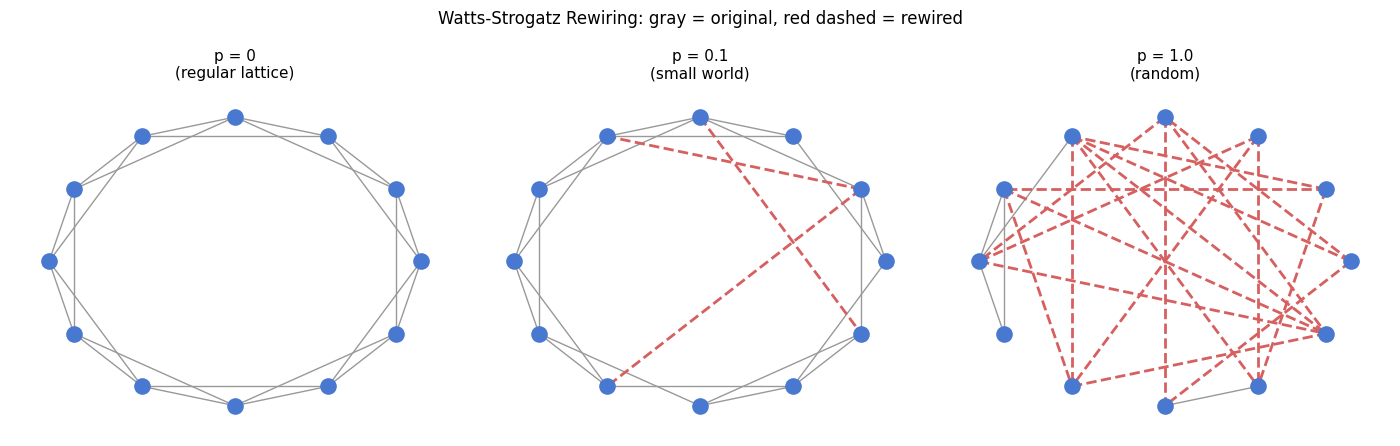

In [12]:
viz.plot_ws_rewiring_demo(n=12, k=4)

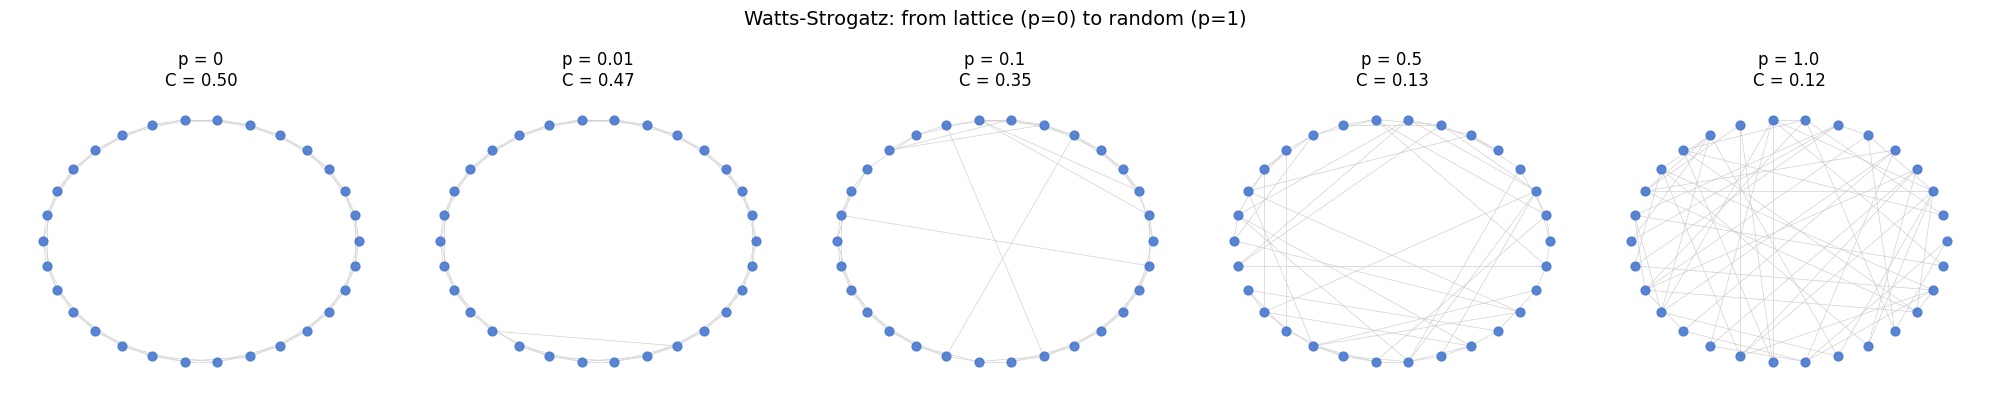

In [13]:
p_values = [0, 0.01, 0.1, 0.5, 1.0]
viz.plot_ws_ring_comparison(p_values, n=30, k=4)

**What to notice**: At p = 0.01 the graph still *looks* like a ring -- almost all edges are local. Yet even these few rewired shortcuts dramatically reduce path lengths. This is the key insight: structure can look highly ordered while distances behave as if the network were random.

In [14]:
# Compute C and L at each p
print(f"{'p':>6s} {'C':>8s} {'L':>8s}")
print("-" * 24)
for p in p_values:
    G_ws = models.watts_strogatz(200, 6, p, seed=SEED)
    C = nx.average_clustering(G_ws)
    L = nx.average_shortest_path_length(G_ws)
    print(f"{p:6.2f} {C:8.4f} {L:8.2f}")

     p        C        L
------------------------
  0.00   0.6000    17.09
  0.01   0.5822     9.69
  0.10   0.4379     4.42
  0.50   0.1039     3.24
  1.00   0.0320     3.15


**The asymmetry**: Path length (L) is highly sensitive to the *first few* rewirings -- a handful of shortcuts create "express lanes" across the ring. Clustering (C) is robust -- it takes *many* rewirings to disrupt the local triangles. This asymmetry is what creates the small-world regime.

---
## 6. The Sweet Spot: C(p) and L(p) vs p

The classic Watts-Strogatz figure normalizes clustering and path length by their values at p=0.
The key insight: **path length drops dramatically with just a tiny bit of rewiring**, while
**clustering stays high** until much more rewiring occurs.

**From formula to code**: The sweep below normalizes both metrics by their values at p = 0:

$$\frac{C(p)}{C(0)} \qquad \text{and} \qquad \frac{L(p)}{L(0)}$$

This puts both curves on a common 0-to-1 scale so we can compare their *rates of change*. At p = 0 both ratios equal 1.0 by definition; as p → 1 both approach their random-graph values. The key question is: **at what p does each curve start to drop?** The code first builds the p = 0 baseline graph, records `C0` and `L0`, then divides each subsequent measurement by these baselines.

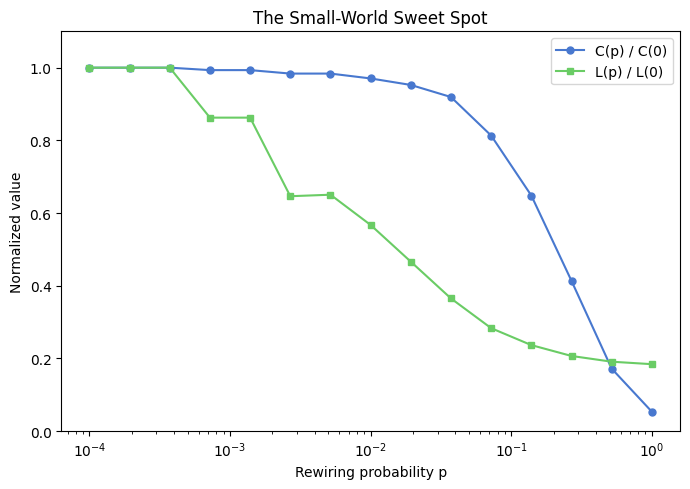

In [15]:
# Sweep over p values (log-spaced)
n_ws, k_ws = 200, 6
p_sweep = np.logspace(-4, 0, 15)

# Get baseline at p=0
G0 = models.watts_strogatz(n_ws, k_ws, 0, seed=SEED)
C0 = nx.average_clustering(G0)
L0 = nx.average_shortest_path_length(G0)

C_list, L_list = [], []
for p in p_sweep:
    G_ws = models.watts_strogatz(n_ws, k_ws, p, seed=SEED)
    C_list.append(nx.average_clustering(G_ws) / C0)
    L_list.append(nx.average_shortest_path_length(G_ws) / L0)

viz.plot_ws_sweep(p_sweep, C_list, L_list)

**The small-world regime**: Look at the gap between the two curves in the range p ~ 0.001 to p ~ 0.1. In this zone, L has already dropped to near its random-graph value while C remains close to its lattice value. This is the "sweet spot" -- networks with both short paths and high clustering. Most real social networks live in this regime.

**Before you look**: The cell below sweeps k from 4 to 20 and measures the area between the C(p) and L(p) curves — a quantitative proxy for how wide the sweet spot is. Predict: as k increases, will the normalized sweet spot grow wider, narrower, or stay the same?

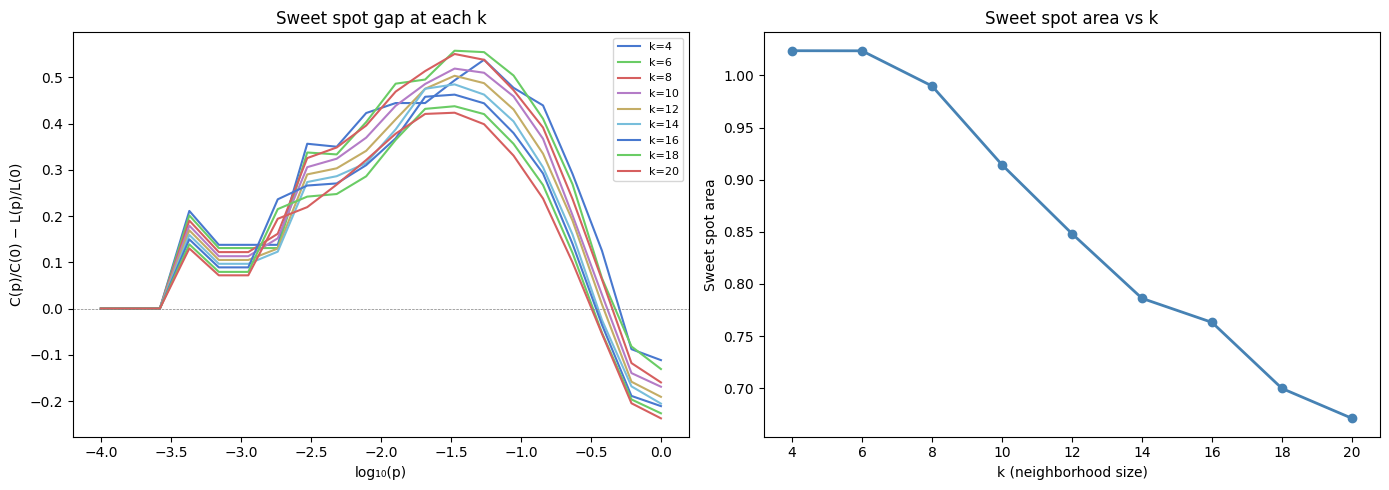

k  | Sweet spot area
---|----------------
 4 | 1.024
 6 | 1.024
 8 | 0.990
10 | 0.914
12 | 0.848
14 | 0.786
16 | 0.763
18 | 0.700
20 | 0.671


In [16]:
# Sweep k values and compute the "sweet spot area" between C(p) and L(p) curves
n_ws_k = 200
k_values = range(4, 22, 2)  # k must be even for WS model
p_sweep_k = np.logspace(-4, 0, 20)
log_p = np.log10(p_sweep_k)

gap_curves = {}
areas = {}

for k_val in k_values:
    G0_k = models.watts_strogatz(n_ws_k, k_val, 0, seed=SEED)
    C0_k = nx.average_clustering(G0_k)
    L0_k = nx.average_shortest_path_length(G0_k)

    C_norm, L_norm = [], []
    for p in p_sweep_k:
        G_ws_k = models.watts_strogatz(n_ws_k, k_val, p, seed=SEED)
        C_norm.append(nx.average_clustering(G_ws_k) / C0_k)
        L_norm.append(nx.average_shortest_path_length(G_ws_k) / L0_k)

    gap = np.array(C_norm) - np.array(L_norm)
    gap_curves[k_val] = gap
    areas[k_val] = np.trapezoid(gap, log_p)

viz.plot_ws_k_sweep(k_values, p_sweep_k, gap_curves, areas)

print("k  | Sweet spot area")
print("---|----------------")
for k_val in k_values:
    print(f"{k_val:2d} | {areas[k_val]:.3f}")

**What you should see**: The sweet spot area **decreases monotonically** as k grows — the opposite of what you might expect. Although higher k raises *absolute* clustering, the normalization C(p)/C(0) cancels that out. What matters is the *relative* rate of decay, and two effects work against high k:

1. **Clustering erodes faster** — with more edges per node, each rewiring disrupts more triangles proportionally, so C(p)/C(0) drops sooner.
2. **Path length gains less** — the baseline L(0) is already short for dense rings, so rewiring yields less *relative* improvement in L(p)/L(0).

The net effect: at high k, L doesn't drop as far ahead of C, and the gap narrows. The small-world sweet spot is widest for **sparse rings** (low k) where the contrast between local structure and random shortcuts is most extreme.

Increasing *n* (not shown here) shifts the transition zone rightward: larger rings need more shortcuts to bridge distant parts, so L drops at slightly higher p. The qualitative shape (L drops first, C drops later) is universal.

---
## 7. Kleinberg's Navigable Small Worlds

Watts-Strogatz showed that short paths *exist* in small-world networks. But Milgram's experiment revealed something deeper: people can actually *find* those short paths using only local information — they don't have a map of the whole network!

This distinction is crucial. In a random graph, short paths exist but no one can find them without a global map — you'd need to run BFS on the entire network. In Milgram's experiment, people used a simple heuristic: forward the letter to whoever seems "closer" to the target (by geography, profession, or social circle). Somehow, this greedy strategy works.

In 2000, Jon Kleinberg asked: **what network structure allows decentralized (greedy) search to find short paths?**

### The Model

Start with a 2D grid where each node connects to its local neighbors. Then add **long-range links** with probability proportional to distance^(-r):

$$P(\text{link to } v) \;\propto\; d(u,v)^{-r}$$

The exponent *r* controls the reach of long-range links:
- **r = 0**: uniform random links (like adding random shortcuts)
- **r = 2**: optimal for greedy routing — links are "tuned" to the grid dimension
- **r >> 2**: links are almost all local (no useful shortcuts)

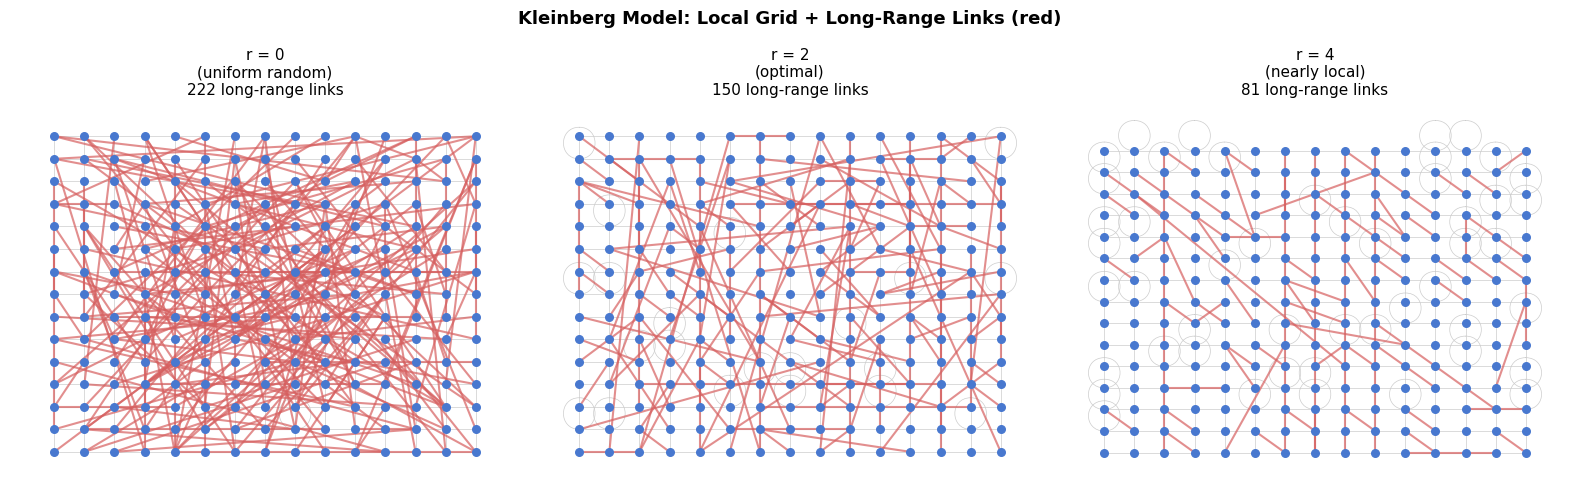

In [17]:
# Kleinberg grids at r=0, r=2, r=4
r_values = [0, 2, 4]
r_labels = ["r = 0\n(uniform random)", "r = 2\n(optimal)", "r = 4\n(nearly local)"]
grids = [models.kleinberg_grid(n=15, r=r_val, q=1) for r_val in r_values]

viz.plot_kleinberg_panels(grids, r_values, r_labels=r_labels)

**What each r value means**: At r=0 (left), long-range links jump uniformly across the grid — some reach very far, but they don't "know" about distance. At r=2 (center), links span a wide range of distances with the right balance — some reach far, but most connect moderately distant nodes. At r=4 (right), almost all links stay close to the source — essentially just thickening the local neighborhood.

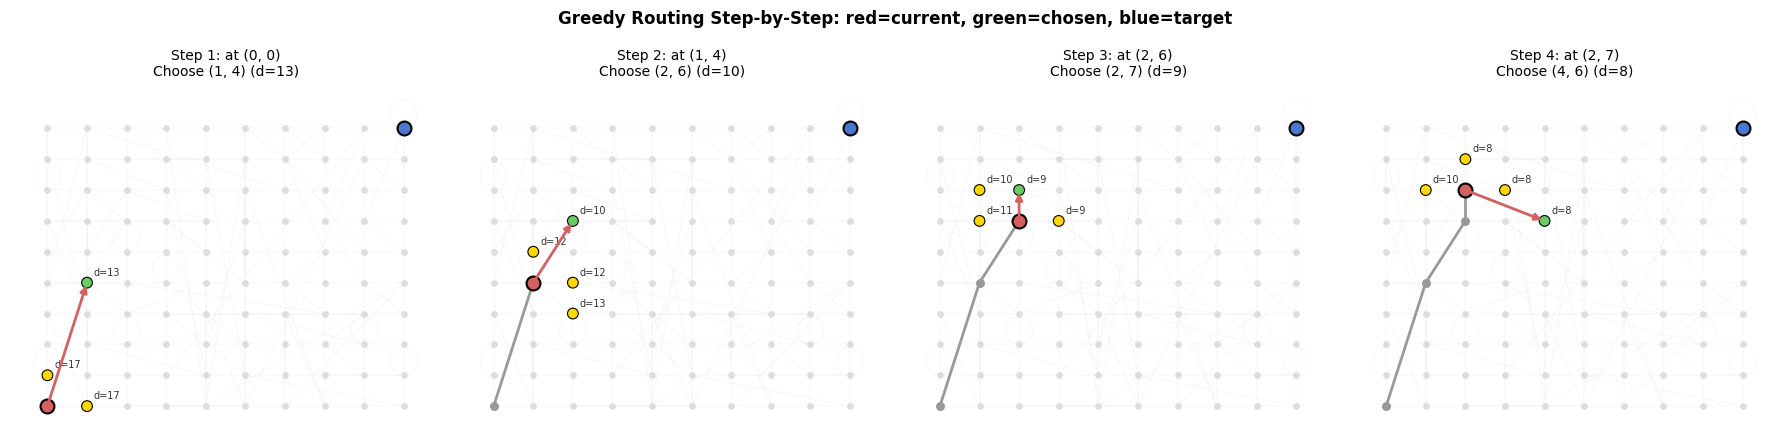

In [18]:
# Step-by-step greedy routing: show the decision at each hop
G_step, pos_step = models.kleinberg_grid(n=10, r=2, q=1, seed=SEED)
source_step, target_step = (0, 0), (9, 9)

# Trace greedy route with decision details
path_step = [source_step]
current = source_step
visited = {source_step}
decisions = []
for _ in range(G_step.number_of_nodes()):
    if current == target_step:
        break
    neighbors = [n for n in G_step.neighbors(current) if n not in visited]
    if not neighbors:
        break
    # Compute distances for all neighbors
    dists = {
        n: abs(n[0] - target_step[0]) + abs(n[1] - target_step[1]) for n in neighbors
    }
    best = min(dists, key=dists.get)
    decisions.append(
        (current, best, dict(sorted(dists.items(), key=lambda x: x[1])[:4]))
    )
    visited.add(best)
    path_step.append(best)
    current = best

viz.plot_greedy_steps(G_step, pos_step, path_step, decisions, target_step, n_panels=4)

**How greedy routing decides**: At each step (panel), the current node (red) evaluates all its neighbors and picks the one closest to the target (blue) by Manhattan distance. The chosen neighbor is green; alternatives are yellow with their distances shown. Notice how long-range links (when available) let the algorithm make big jumps early on, while local grid edges handle the final approach. This is why r=2 works — the long-range links provide useful shortcuts at every distance scale.

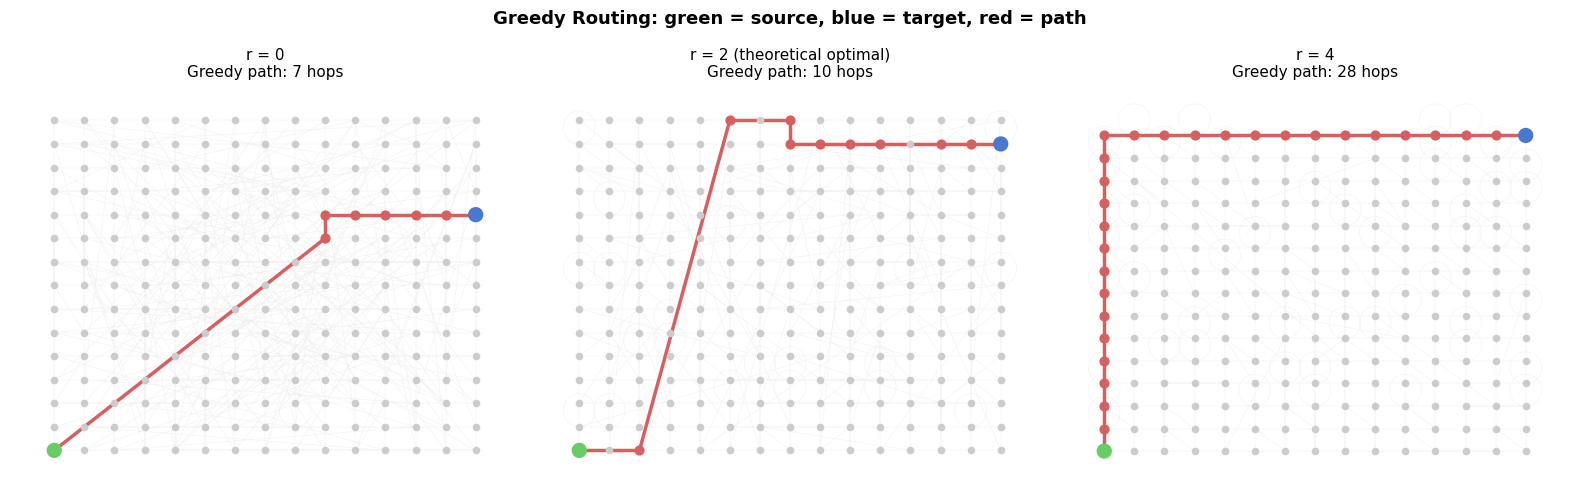

In [19]:
# Visualize a single greedy route at r=0, r=2, r=4
r_values_path = [0, 2, 4]
r_labels_path = ["r = 0", "r = 2 (theoretical optimal)", "r = 4"]
grids_path = [
    models.kleinberg_grid(n=15, r=r_val, q=1, seed=SEED) for r_val in r_values_path
]

paths_data = []
for G_k, pos_k in grids_path:
    nodes_k = list(G_k.nodes())
    source, target = nodes_k[0], nodes_k[-1]
    path = greedy_route(G_k, source, target, pos_k)
    paths_data.append((path, source, target))

viz.plot_greedy_paths(grids_path, paths_data, r_labels=r_labels_path)

In [20]:
# Demo: greedy routing at two scales to show how r affects scaling
rng_k = np.random.default_rng(SEED)
n_pairs = 100

for n_grid in [15, 50]:
    print(f"Grid: {n_grid}x{n_grid} = {n_grid**2} nodes")
    print(f"{'r':>3s} {'Mean greedy':>12s} {'Mean optimal':>13s} {'Diff':>8s}")
    print("-" * 40)
    for r_val in [0, 1, 2, 3, 4]:
        G_k, pos_k = models.kleinberg_grid(n=n_grid, r=r_val, q=1, seed=SEED)
        nodes_k = list(G_k.nodes())
        greedy_lens, optimal_lens = [], []
        for _ in range(n_pairs):
            s, t = tuple(rng_k.choice(len(nodes_k), size=2, replace=False))
            src, tgt = nodes_k[s], nodes_k[t]
            path = greedy_route(G_k, src, tgt, pos_k)
            if path is not None:
                greedy_lens.append(len(path) - 1)
            optimal_lens.append(nx.shortest_path_length(G_k, src, tgt))
        mean_g = np.mean(greedy_lens) if greedy_lens else float("inf")
        mean_o = np.mean(optimal_lens)
        diff = mean_g - mean_o
        print(f"{r_val:3d} {mean_g:12.1f} {mean_o:13.1f} {diff:8.1f}")
    print()

Grid: 15x15 = 225 nodes
  r  Mean greedy  Mean optimal     Diff
----------------------------------------
  0          4.9           3.4      1.5
  1          5.4           3.6      1.7


  2          5.9           4.3      1.6
  3          7.3           5.5      1.8
  4          8.9           6.8      2.1

Grid: 50x50 = 2500 nodes
  r  Mean greedy  Mean optimal     Diff
----------------------------------------
  0         11.7           5.1      6.6
  1         11.1           5.2      5.9
  2         13.4           6.2      7.2
  3         22.1          10.2     11.8
  4         29.3          17.0     12.3



**Reading the tables**: At the small 15×15 grid, r=0 through r=2 all give similar greedy path lengths — the grid is too small for differences to emerge. But compare with the 50×50 grid: r=3 and r=4 have *much* longer greedy paths, while r=0–2 remain relatively short. This is because high-r values concentrate long-range links too close to the source, leaving greedy routing without useful shortcuts for long-distance hops.

Also notice the "Mean optimal" column (computed via BFS with full network knowledge). At low r, the gap between greedy and optimal is modest — greedy routing does a reasonable job with only local information. At high r, greedy routing falls far behind the optimal, because the shortcuts that *do* exist aren't in the direction greedy search looks.

**Why doesn't r=2 clearly win here?** Kleinberg's theorem is an *asymptotic* result: at r=2, greedy path length scales as O(log² n), while all other r values scale polynomially. At grid sizes of a few thousand nodes, we're still in the pre-asymptotic regime where r=0 and r=1 can compete. The advantage of r=2 becomes decisive at much larger scales (tens of thousands of nodes and beyond).

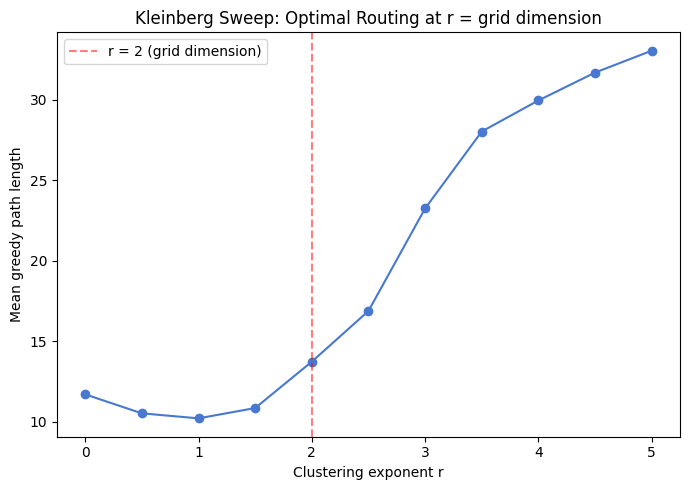

In [21]:
# Sweep r from 0 to 5, measure mean greedy path length
r_sweep = np.linspace(0, 5, 11)
mean_lengths = []
n_grid = 50  # larger grid so scaling differences are visible
n_pairs = 100

for r_val in r_sweep:
    G_k, pos_k = models.kleinberg_grid(n=n_grid, r=r_val, q=1, seed=SEED)
    nodes_k = list(G_k.nodes())
    rng_sweep = np.random.default_rng(SEED)  # reset per r so all use same pairs
    lengths = []
    for _ in range(n_pairs):
        s, t = tuple(rng_sweep.choice(len(nodes_k), size=2, replace=False))
        path = greedy_route(G_k, nodes_k[s], nodes_k[t], pos_k)
        if path is not None:
            lengths.append(len(path) - 1)
    mean_lengths.append(np.mean(lengths) if lengths else float("nan"))

viz.plot_kleinberg_sweep(r_sweep, mean_lengths)

**The shape of the curve**: Greedy path length increases sharply for r > 2, confirming that overly local shortcuts are bad for navigation. The left side of the curve (r < 2) is flatter — uniform or mildly distance-biased links still provide useful shortcuts at this scale.

Kleinberg proved that r = d (where d is the grid dimension, 2 for our 2D grid) is the only exponent where greedy routing achieves O(log² n) scaling. At all other r values, greedy paths grow polynomially with n. At r = 2, the distribution of link distances is **scale-invariant** — there are roughly equal numbers of links at every distance scale, giving greedy search useful shortcuts at every stage of navigation. This theoretical advantage emerges at scales larger than we test here, but the sweep already shows the clear penalty of high r values.

**Why this matters for real networks**: Social networks are navigable because friendships encode geographic and social distance with approximately the right decay exponent. When you forward a letter toward a target, you choose friends who are "closer" in some social dimension — and this works because your friendship distribution has the Kleinberg property.

**Think about it**: What value of r would be optimal for greedy routing on a 1D ring (instead of a 2D grid)? (Answer: r = 1, matching the dimension.)

---
## Summary

| Concept | Key insight |
|---------|-------------|
| **Erdos-Renyi model** | Simplest random graph — Poisson degree distribution, no hubs |
| **Phase transition** | Largest component emerges when avg degree ⟨k⟩ > 1 (theoretical threshold) |
| **Six degrees** | Even large networks have short average paths |
| **Small-world property** | High clustering AND short paths (relative to random); σ = C_ratio / L_ratio > 1 |
| **Watts-Strogatz model** | Ring lattice + tiny rewiring = small world |
| **Sweet spot** | L drops fast, C drops slowly as p increases |
| **Kleinberg model** | Greedy routing optimal when r = grid dimension |
| **Navigability** | Short paths exist AND can be found with local info when r = d |

Next week: **Scale-Free Networks, Hubs & Resilience** — why do some nodes have hundreds of connections?